In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate, underride, configure_plot_style, AIBM_COLORS, code_to_who_country, code_to_wef_country, write_html_table, codes_to_country_names

configure_plot_style()

# Set cutoff year for temporal analysis (excludes 2020+ to avoid COVID-19 distortions)
cutoff_year = 2000

## Load Saved Data

In [3]:
# Code to read the saved data back from HDF5 file
hdf_file = f'../data/hale_analysis_data_{cutoff_year}.h5'

# Read data back
with pd.HDFStore(hdf_file, mode='r') as store:
    predictors_full = store['predictors']
    target = store['target_hale']

In [4]:
# Select only Gap and Mid columns for modeling (exclude Male and Female columns)
# Male and Female columns are kept in predictors_full for counterfactual analysis
gap_mid_cols = [col for col in predictors_full.columns if col.startswith('Gap_') or col.startswith('Mid_')]
# Add female-only indicators if present (e.g., MaternalMortality_Female)
if 'MaternalMortality_Female' in predictors_full.columns:
    gap_mid_cols += ['MaternalMortality_Female']
predictors = predictors_full[gap_mid_cols].copy()

# Display predictor information
print(f"Number of predictors: {len(predictors.columns)}")
print(f"Number of countries: {len(predictors)}")
print(f"\nSample of predictor column names:")
print(list(predictors.columns[:10]))
print(f"\nTotal columns in predictors_full (including Male/Female): {len(predictors_full.columns)}")

Number of predictors: 22
Number of countries: 38

Sample of predictor column names:
['Gap_Alcohol', 'Mid_Alcohol', 'Gap_ChronicRespiratory', 'Mid_ChronicRespiratory', 'Gap_UnintentionalInjury', 'Mid_UnintentionalInjury', 'Gap_RoadTraffic', 'Mid_RoadTraffic', 'Gap_Diabetes', 'Mid_Diabetes']

Total columns in predictors_full (including Male/Female): 44


## Model Fitting


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error

# Prepare data: X (predictors) and y (target)
# Predictors are already in Mid + Gap format (from eda.md)
X = predictors.copy()
y = target.copy()

# Display data shape
pd.DataFrame({
    'Data': ['Predictors (X)', 'Target (y)'],
    'Shape': [X.shape, y.shape],
    'Countries': [X.shape[0], y.shape[0]]
})

,Data,Shape,Countries
0,Predictors (X),"(38, 22)",38
1,Target (y),"(38,)",38


In [6]:
# Set up cross-validation (5-fold for small sample size)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Display CV setup
f"Using {cv.n_splits}-fold cross-validation for model selection"

'Using 5-fold cross-validation for model selection'

### Fit Multiple Models

In [7]:
# Define parameter grids for each model
ridge_params = {'ridge__alpha': np.logspace(-2, 4, 50)}  # Regularization strength
lasso_params = {'lasso__alpha': np.logspace(-3, 1, 50)}
elastic_net_params = {
    'elasticnet__alpha': np.logspace(-3, 1, 20),
    'elasticnet__l1_ratio': np.linspace(0.1, 0.9, 9)  # 0=Ridge, 1=Lasso
}

# Create pipelines with StandardScaler and models
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

elastic_net_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(max_iter=10000))
])

In [8]:
# Fit Ridge Regression with cross-validation
print("Fitting Ridge Regression...")
ridge_grid = GridSearchCV(ridge_pipeline, ridge_params, cv=cv, 
                          scoring='r2', n_jobs=-1, verbose=1)
ridge_grid.fit(X, y)

ridge_best_score = ridge_grid.best_score_
ridge_best_params = ridge_grid.best_params_
ridge_best_model = ridge_grid.best_estimator_

pd.DataFrame({
    'Model': ['Ridge'],
    'Best_CV_R2': [ridge_best_score],
    'Best_Alpha': [ridge_best_params['ridge__alpha']]
})

Fitting Ridge Regression...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,Model,Best_CV_R2,Best_Alpha
0,Ridge,0.672916,20.235896


In [9]:
# Fit Lasso Regression with cross-validation
print("Fitting Lasso Regression...")
lasso_grid = GridSearchCV(lasso_pipeline, lasso_params, cv=cv,
                          scoring='r2', n_jobs=-1, verbose=1)
lasso_grid.fit(X, y)

lasso_best_score = lasso_grid.best_score_
lasso_best_params = lasso_grid.best_params_
lasso_best_model = lasso_grid.best_estimator_

pd.DataFrame({
    'Model': ['Lasso'],
    'Best_CV_R2': [lasso_best_score],
    'Best_Alpha': [lasso_best_params['lasso__alpha']]
})

Fitting Lasso Regression...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,Model,Best_CV_R2,Best_Alpha
0,Lasso,0.618402,0.062506


In [10]:
# Fit Elastic Net with cross-validation
print("Fitting Elastic Net...")
elastic_net_grid = GridSearchCV(elastic_net_pipeline, elastic_net_params, cv=cv,
                                 scoring='r2', n_jobs=-1, verbose=1)
elastic_net_grid.fit(X, y)

elastic_net_best_score = elastic_net_grid.best_score_
elastic_net_best_params = elastic_net_grid.best_params_
elastic_net_best_model = elastic_net_grid.best_estimator_

pd.DataFrame({
    'Model': ['Elastic Net'],
    'Best_CV_R2': [elastic_net_best_score],
    'Best_Alpha': [elastic_net_best_params['elasticnet__alpha']],
    'Best_L1_Ratio': [elastic_net_best_params['elasticnet__l1_ratio']]
})

Fitting Elastic Net...
Fitting 5 folds for each of 180 candidates, totalling 900 fits


,Model,Best_CV_R2,Best_Alpha,Best_L1_Ratio
0,Elastic Net,0.631629,0.545559,0.1


## Model Performance Summary

In [11]:
# Calculate MAE from cross-validation for each model
ridge_mae_scores = -cross_val_score(ridge_best_model, X, y, cv=cv, scoring='neg_mean_absolute_error')
lasso_mae_scores = -cross_val_score(lasso_best_model, X, y, cv=cv, scoring='neg_mean_absolute_error')
elastic_net_mae_scores = -cross_val_score(elastic_net_best_model, X, y, cv=cv, scoring='neg_mean_absolute_error')

# Compare cross-validation scores
model_comparison = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Elastic Net'],
    'CV_R2_Score': [ridge_best_score, lasso_best_score, elastic_net_best_score],
    'CV_MAE_Mean': [
        ridge_mae_scores.mean(),
        lasso_mae_scores.mean(),
        elastic_net_mae_scores.mean()
    ],
    'CV_MAE_Std': [
        ridge_mae_scores.std(),
        lasso_mae_scores.std(),
        elastic_net_mae_scores.std()
    ]
})

model_comparison_sorted = model_comparison.sort_values('CV_R2_Score', ascending=False)
model_comparison_sorted

,Model,CV_R2_Score,CV_MAE_Mean,CV_MAE_Std
0,Ridge,0.672916,0.508279,0.142520
2,Elastic Net,0.631629,0.567747,0.195292
1,Lasso,0.618402,0.594301,0.286594


In [12]:
# Write model comparison table to HTML
write_html_table(model_comparison_sorted, f'jb/tables/model_comparison_hale_{cutoff_year}.html')

In [13]:
primary_model = elastic_net_best_model
primary_model_name = 'Elastic Net'

In [14]:
# Calculate predictions and residuals
y_pred = primary_model.predict(X)
y_pred = pd.Series(y_pred, index=y.index)
residuals = y - y_pred

In [15]:
# Calculate R² on full dataset (in-sample/training R²)
# Note: This is higher than cross-validation R² because the model is evaluated on the same
# data it was trained on. The cross-validation R² (~0.74) is a better estimate of 
# out-of-sample performance (generalization). The difference indicates some overfitting,
# which is expected with a small sample size (n~30-40 countries) and many predictors.
r2_full = primary_model.score(X, y)
print(f"R² on full dataset (in-sample): {r2_full:.4f}")
print(f"Cross-validation R² (out-of-sample): {elastic_net_best_score:.4f}")
print(f"MAE: {mean_absolute_error(y, y_pred):.4f} years")

R² on full dataset (in-sample): 0.8958
Cross-validation R² (out-of-sample): 0.6316
MAE: 0.4490 years


In [16]:
# Display model performance summary
print("\n" + "="*60)
print("Elastic Net Model Performance Summary (Mid + Gap)")
print("="*60)
print(f"Cross-validation R²: {elastic_net_best_score:.4f}")
print(f"In-sample R²: {r2_full:.4f}")
print(f"MAE: {mean_absolute_error(y, y_pred):.4f} years")
print(f"Number of predictors: {len(X.columns)}")
print(f"Number of non-zero coefficients: {np.sum(elastic_net_best_model.named_steps['elasticnet'].coef_ != 0)}")


Elastic Net Model Performance Summary (Mid + Gap)
Cross-validation R²: 0.6316
In-sample R²: 0.8958
MAE: 0.4490 years
Number of predictors: 22
Number of non-zero coefficients: 19


In [17]:
# Extract coefficients from each model (on standardized scale)
ridge_coefs = pd.DataFrame({
    'Predictor': X.columns,
    'Ridge_Coefficient': ridge_best_model.named_steps['ridge'].coef_
}).sort_values('Ridge_Coefficient', key=abs, ascending=False)

lasso_coefs = pd.DataFrame({
    'Predictor': X.columns,
    'Lasso_Coefficient': lasso_best_model.named_steps['lasso'].coef_
}).sort_values('Lasso_Coefficient', key=abs, ascending=False)

elastic_net_coefs = pd.DataFrame({
    'Predictor': X.columns,
    'ElasticNet_Coefficient': elastic_net_best_model.named_steps['elasticnet'].coef_
}).sort_values('ElasticNet_Coefficient', key=abs, ascending=False)

# Merge coefficient comparisons
coef_comparison = ridge_coefs.merge(lasso_coefs, on='Predictor').merge(elastic_net_coefs, on='Predictor')
coef_comparison

,Predictor,Ridge_Coefficient,Lasso_Coefficient,ElasticNet_Coefficient
0,Gap_UnintentionalInjury,0.217483,0.432851,0.235100
1,Gap_Neoplasms,0.215018,0.302668,0.190130
2,Mid_Homicide,0.199300,0.451005,0.182359
3,Gap_ChronicRespiratory,0.190640,0.178385,0.143354
4,Gap_Suicide,0.189083,0.214265,0.199780
5,Gap_Homicide,0.186658,0.000000,0.162171
6,Mid_Suicide,0.180955,0.226128,0.188580
7,Mid_RoadTraffic,0.175638,0.225600,0.181978
8,Mid_UnintentionalInjury,0.146793,0.064975,0.149236
9,Mid_ChronicRespiratory,-0.145699,-0.151765,-0.139462


In [18]:
# Write coefficient comparison table to HTML (only non-zero coefficients)
coef_comparison_nonzero = coef_comparison[
    (coef_comparison['Ridge_Coefficient'] != 0) | 
    (coef_comparison['Lasso_Coefficient'] != 0) | 
    (coef_comparison['ElasticNet_Coefficient'] != 0)
].copy()
write_html_table(coef_comparison_nonzero, f'jb/tables/coefficient_comparison_hale_{cutoff_year}.html')

In [19]:
# Count non-zero coefficients (feature selection in Lasso/Elastic Net)
feature_selection_summary = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Elastic Net'],
    'Total_Predictors': [len(X.columns), len(X.columns), len(X.columns)],
    'Non_Zero_Coefficients': [
        np.sum(ridge_best_model.named_steps['ridge'].coef_ != 0),
        np.sum(lasso_best_model.named_steps['lasso'].coef_ != 0),
        np.sum(elastic_net_best_model.named_steps['elasticnet'].coef_ != 0)
    ],
    'Zero_Coefficients': [
        np.sum(ridge_best_model.named_steps['ridge'].coef_ == 0),
        np.sum(lasso_best_model.named_steps['lasso'].coef_ == 0),
        np.sum(elastic_net_best_model.named_steps['elasticnet'].coef_ == 0)
    ]
})

feature_selection_summary

,Model,Total_Predictors,Non_Zero_Coefficients,Zero_Coefficients
0,Ridge,22,22,0
1,Lasso,22,13,9
2,Elastic Net,22,19,3


In [20]:
# Write feature selection summary table to HTML
write_html_table(feature_selection_summary, f'jb/tables/feature_selection_summary_hale_{cutoff_year}.html')

## Model Diagnostics


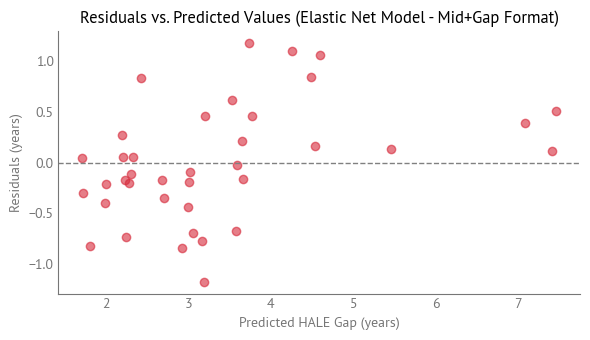

In [21]:
# Residual vs. Predicted values plot
plt.scatter(y_pred, residuals, color=AIBM_COLORS['crimson'], alpha=0.6)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
decorate(xlabel='Predicted HALE Gap (years)',
         ylabel='Residuals (years)',
         title='Residuals vs. Predicted Values (Elastic Net Model - Mid+Gap Format)')

plt.savefig(f'jb/figs/residuals_vs_predicted_hale_{cutoff_year}.png', dpi=300, bbox_inches='tight')

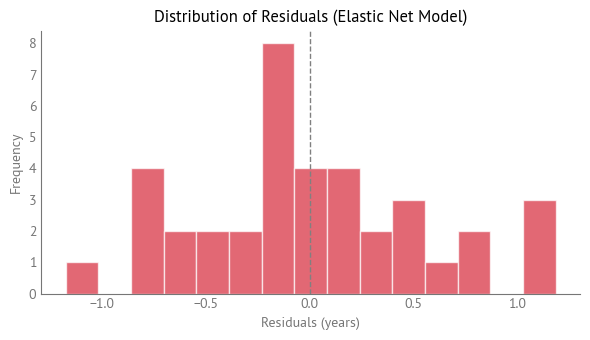

In [22]:
# Histogram of residuals
plt.hist(residuals, bins=15, color=AIBM_COLORS['crimson'], edgecolor='white', alpha=0.7)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
decorate(xlabel='Residuals (years)',
         ylabel='Frequency',
         title='Distribution of Residuals (Elastic Net Model)')

plt.savefig(f'jb/figs/residuals_distribution_hale_{cutoff_year}.png', dpi=300, bbox_inches='tight')

In [23]:
# Identify potential outliers (residuals > 2 standard deviations)
outlier_threshold = 2 * residuals.std()
outliers = residuals[abs(residuals) > outlier_threshold]

outlier_df = pd.DataFrame({
    'Country': codes_to_country_names(outliers.index),
    'Actual_HALE_Gap': y[outliers.index],
    'Predicted_HALE_Gap': y_pred[outliers.index],
    'Residual': outliers.values,
    'Abs_Residual': abs(outliers.values)
}).sort_values('Abs_Residual', ascending=False)

outlier_df if not outlier_df.empty else "No outliers detected (|residual| > 2 std)"

,Country,Actual_HALE_Gap,Predicted_HALE_Gap,Residual,Abs_Residual
Code,,,,,
KOR,South Korea,4.914148,3.731431,1.182717,1.182717
GRC,Greece,2.017895,3.191412,-1.173517,1.173517


In [24]:
# Residuals by country (sorted by absolute residual)
residuals_by_country = pd.DataFrame({
    'Country': codes_to_country_names(residuals.index),
    'Actual_HALE_Gap': y.values,
    'Predicted_HALE_Gap': y_pred,
    'Residual': residuals.values,
    'Abs_Residual': abs(residuals.values)
}).sort_values('Abs_Residual', ascending=False)

residuals_by_country.head(10)

,Country,Actual_HALE_Gap,Predicted_HALE_Gap,Residual,Abs_Residual
Code,,,,,
KOR,South Korea,4.914148,3.731431,1.182717,1.182717
GRC,Greece,2.017895,3.191412,-1.173517,1.173517
SVK,Slovakia,5.361061,4.256148,1.104913,1.104913
POL,Poland,5.657452,4.597402,1.060050,1.060050
CRI,Costa Rica,2.072570,2.918312,-0.845742,0.845742
COL,Colombia,5.326732,4.481868,0.844864,0.844864
TUR,Türkiye,3.260272,2.422854,0.837417,0.837417
ISL,Iceland,0.977728,1.797514,-0.819786,0.819786
CHL,Chile,2.385867,3.160032,-0.774165,0.774165


In [25]:
# Write residuals by country table to HTML
write_html_table(residuals_by_country, f'jb/tables/residuals_by_country_hale_{cutoff_year}.html')

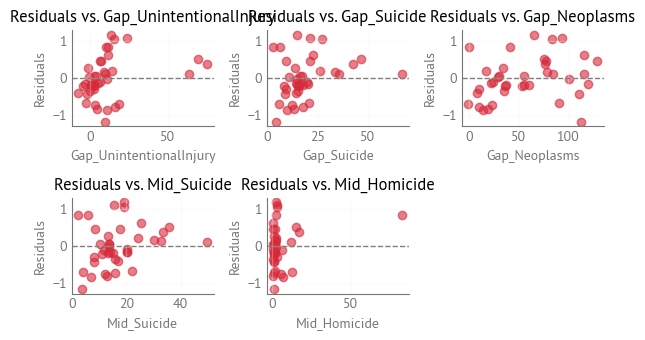

In [26]:
# Check for patterns: plot residuals vs. each predictor (top predictors by absolute coefficient)
# Get top predictors by absolute coefficient value
coef_abs = pd.Series(elastic_net_best_model.named_steps['elasticnet'].coef_, index=X.columns).abs()
top_predictors = coef_abs.nlargest(5).index.values

fig, axes = plt.subplots(2, 3)
axes = axes.flatten()

for i, pred in enumerate(top_predictors):
    if i < len(axes):
        axes[i].scatter(X[pred], residuals, color=AIBM_COLORS['crimson'], alpha=0.6)
        axes[i].axhline(y=0, color='gray', linestyle='--', linewidth=1)
        axes[i].set_xlabel(pred)
        axes[i].set_ylabel('Residuals')
        axes[i].set_title(f'Residuals vs. {pred}')
        axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for i in range(len(top_predictors), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig(f'jb/figs/residuals_vs_predictors_hale_{cutoff_year}.png', dpi=300, bbox_inches='tight')

## Importance Analysis


In [27]:
# Create dictionary mapping predictor names to Elastic Net coefficients
# This makes it easier to look up coefficients by predictor name
elastic_net_coefs_dict = dict(zip(X.columns, elastic_net_best_model.named_steps['elasticnet'].coef_))

In [28]:
# Feature importance = |coefficient| × std(predictor)
# This measures the contribution of each predictor to the HALE gap variation
# Since predictors are standardized, we multiply by the original standard deviation
# to get importance on the original scale

predictor_importance = []

for predictor in X.columns:
    coef = elastic_net_coefs_dict.get(predictor, 0)
    
    # Get the original (unstandardized) standard deviation
    # The scaler was fit on X, so we can get the std from predictors DataFrame
    if predictor in predictors.columns:
        std_original = predictors[predictor].std()
        importance = abs(coef) * std_original
    else:
        std_original = 0
        importance = 0
    
    predictor_importance.append({
        'Predictor': predictor,
        'Coefficient': coef,
        'Std_Original': std_original,
        'Importance': importance
    })

importance_df = pd.DataFrame(predictor_importance).sort_values('Importance', ascending=False)
importance_df

,Predictor,Coefficient,Std_Original,Importance
11,Mid_Cardiovascular,0.096204,160.665793,15.456649
18,Gap_Neoplasms,0.190130,38.964324,7.408290
4,Gap_UnintentionalInjury,0.235100,18.591835,4.370950
14,Gap_Homicide,0.162171,21.699145,3.518972
16,Gap_Suicide,0.199780,12.676963,2.532603
15,Mid_Homicide,0.182359,13.420061,2.447272
3,Mid_ChronicRespiratory,-0.139462,15.925398,2.220985
5,Mid_UnintentionalInjury,0.149236,13.880258,2.071430
17,Mid_Suicide,0.188580,9.796033,1.847337
2,Gap_ChronicRespiratory,0.143354,11.159731,1.599787


In [29]:
# Write non-zero importance rows to HTML
importance_nonzero = importance_df[importance_df['Importance'] != 0].copy()
write_html_table(importance_nonzero, f'jb/tables/predictor_importance_hale_{cutoff_year}.html')
importance_nonzero

,Predictor,Coefficient,Std_Original,Importance
11,Mid_Cardiovascular,0.096204,160.665793,15.456649
18,Gap_Neoplasms,0.190130,38.964324,7.408290
4,Gap_UnintentionalInjury,0.235100,18.591835,4.370950
14,Gap_Homicide,0.162171,21.699145,3.518972
16,Gap_Suicide,0.199780,12.676963,2.532603
15,Mid_Homicide,0.182359,13.420061,2.447272
3,Mid_ChronicRespiratory,-0.139462,15.925398,2.220985
5,Mid_UnintentionalInjury,0.149236,13.880258,2.071430
17,Mid_Suicide,0.188580,9.796033,1.847337
2,Gap_ChronicRespiratory,0.143354,11.159731,1.599787


### Visualize Predictor Importance

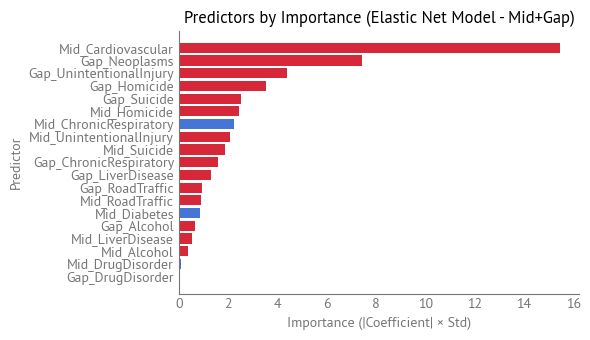

In [30]:
# Create bar chart of all predictors with non-zero coefficients by importance
non_zero_importance = importance_df[importance_df['Importance'] != 0].copy()

colors = [AIBM_COLORS['crimson'] if x > 0 else AIBM_COLORS['blue'] 
          for x in non_zero_importance['Coefficient']]
plt.barh(range(len(non_zero_importance)), non_zero_importance['Importance'], color=colors)
plt.yticks(range(len(non_zero_importance)), non_zero_importance['Predictor'])
plt.gca().invert_yaxis()
decorate(xlabel='Importance (|Coefficient| × Std)',
         ylabel='Predictor',
         title='Predictors by Importance (Elastic Net Model - Mid+Gap)')

plt.savefig(f'jb/figs/predictor_importance_hale_{cutoff_year}.png', dpi=300, bbox_inches='tight')

### Importance by Indicator

In [31]:
# Extract indicator names from Mid_ and Gap_ columns
all_indicators = set()
for col in predictors.columns:
    if col.startswith('Mid_'):
        indicator_name = col[4:]  # Remove 'Mid_' prefix
        all_indicators.add(indicator_name)
    elif col.startswith('Gap_'):
        indicator_name = col[4:]  # Remove 'Gap_' prefix
        all_indicators.add(indicator_name)

# Indicators with both Mid and Gap (most indicators)
mid_gap_indicators = sorted([ind for ind in all_indicators 
                             if f'Mid_{ind}' in predictors.columns and f'Gap_{ind}' in predictors.columns])

# Female-only indicators (e.g., MaternalMortality)
# Automatically include if present in predictors
female_only_indicators = []
if 'MaternalMortality_Female' in predictors.columns:
    female_only_indicators = ['MaternalMortality']
female_only_indicators

[]

In [32]:
# Aggregate importance by indicator (sum of Mid and Gap importance)
indicator_importance = {}

for indicator in mid_gap_indicators:
    mid_col = f'Mid_{indicator}'
    gap_col = f'Gap_{indicator}'
    
    mid_imp = importance_df[importance_df['Predictor'] == mid_col]['Importance'].values
    gap_imp = importance_df[importance_df['Predictor'] == gap_col]['Importance'].values
    
    if len(mid_imp) > 0 and len(gap_imp) > 0:
        total_importance = mid_imp[0] + gap_imp[0]
        indicator_importance[indicator] = {
            'Mid_Importance': mid_imp[0],
            'Gap_Importance': gap_imp[0],
            'Total_Importance': total_importance
        }

# Add female-only indicators (if any)
for indicator in female_only_indicators:
    # Check for any column matching this indicator
    matching_cols = [col for col in predictors.columns if indicator in col]
    print(matching_cols)
    if matching_cols:
        col = matching_cols[0]
        col_imp = importance_df[importance_df['Predictor'] == col]['Importance'].values
        if len(col_imp) > 0:
            indicator_importance[indicator] = {
                'Mid_Importance': np.nan,
                'Gap_Importance': np.nan,
                'Total_Importance': col_imp[0]
            }

indicator_importance_df = pd.DataFrame(indicator_importance).T
indicator_importance_df = indicator_importance_df.sort_values('Total_Importance', ascending=False)
indicator_importance_df

,Mid_Importance,Gap_Importance,Total_Importance
Cardiovascular,15.456649,0.000000,15.456649
Neoplasms,0.000000,7.408290,7.408290
UnintentionalInjury,2.071430,4.370950,6.442379
Homicide,2.447272,3.518972,5.966244
Suicide,1.847337,2.532603,4.379940
ChronicRespiratory,2.220985,1.599787,3.820772
RoadTraffic,0.878474,0.944868,1.823342
LiverDisease,0.538898,1.277439,1.816337
Alcohol,0.350957,0.662861,1.013819
Diabetes,0.844713,0.000000,0.844713


In [33]:
# Write indicator importance table to HTML
indicator_importance_formatted = indicator_importance_df.reset_index().rename(columns={'index': 'Indicator'})
write_html_table(indicator_importance_formatted, f'jb/tables/indicator_importance_hale_{cutoff_year}.html')
indicator_importance_formatted

,Indicator,Mid_Importance,Gap_Importance,Total_Importance
0,Cardiovascular,15.456649,0.000000,15.456649
1,Neoplasms,0.000000,7.408290,7.408290
2,UnintentionalInjury,2.071430,4.370950,6.442379
3,Homicide,2.447272,3.518972,5.966244
4,Suicide,1.847337,2.532603,4.379940
5,ChronicRespiratory,2.220985,1.599787,3.820772
6,RoadTraffic,0.878474,0.944868,1.823342
7,LiverDisease,0.538898,1.277439,1.816337
8,Alcohol,0.350957,0.662861,1.013819
9,Diabetes,0.844713,0.000000,0.844713


### Visualize Indicator Importance

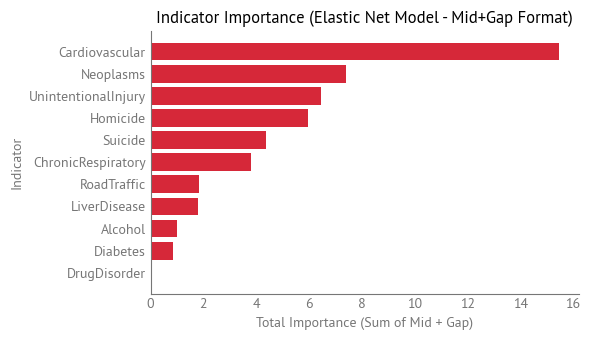

In [34]:
# Bar chart of indicator-level importance
colors_bar = [AIBM_COLORS['crimson'] for _ in range(len(indicator_importance_df))]
plt.barh(range(len(indicator_importance_df)), indicator_importance_df['Total_Importance'], 
         color=colors_bar)
plt.yticks(range(len(indicator_importance_df)), indicator_importance_df.index)
plt.gca().invert_yaxis()
decorate(xlabel='Total Importance (Sum of Mid + Gap)',
         ylabel='Indicator',
         title='Indicator Importance (Elastic Net Model - Mid+Gap Format)')

plt.savefig(f'jb/figs/indicator_importance_hale_{cutoff_year}.png', dpi=300, bbox_inches='tight')

## Statsmodels Linear Regression with Selected Predictors

In [35]:
import statsmodels.api as sm

# Extract predictors with non-zero coefficients from Elastic Net
elastic_net_coefs = elastic_net_best_model.named_steps['elasticnet'].coef_
non_zero_mask = elastic_net_coefs != 0
selected_predictors = X.columns[non_zero_mask].tolist()

print(f"Selected predictors (non-zero Elastic Net coefficients): {len(selected_predictors)}")
print(selected_predictors)

Selected predictors (non-zero Elastic Net coefficients): 19
['Gap_Alcohol', 'Mid_Alcohol', 'Gap_ChronicRespiratory', 'Mid_ChronicRespiratory', 'Gap_UnintentionalInjury', 'Mid_UnintentionalInjury', 'Gap_RoadTraffic', 'Mid_RoadTraffic', 'Mid_Diabetes', 'Mid_Cardiovascular', 'Gap_DrugDisorder', 'Mid_DrugDisorder', 'Gap_Homicide', 'Mid_Homicide', 'Gap_Suicide', 'Mid_Suicide', 'Gap_Neoplasms', 'Gap_LiverDisease', 'Mid_LiverDisease']


In [36]:
# Standardize the selected predictors to match Elastic Net preprocessing
# Create a new StandardScaler and fit it only on the selected predictors
# (We can't reuse the Elastic Net scaler because it was fit on all predictors)
from sklearn.preprocessing import StandardScaler

# Create subset of X with only selected predictors
X_selected = X[selected_predictors].copy()

# Create and fit a new scaler on the selected predictors only
ols_scaler = StandardScaler()
X_selected_standardized = pd.DataFrame(
    ols_scaler.fit_transform(X_selected),
    index=X_selected.index,
    columns=X_selected.columns
)

# Add constant term for intercept
X_selected_with_const = sm.add_constant(X_selected_standardized)

# Fit OLS regression on standardized predictors
ols_model = sm.OLS(y, X_selected_with_const).fit()

# Display summary
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               HALE_gap   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     13.89
Date:                Sat, 13 Dec 2025   Prob (F-statistic):           3.70e-07
Time:                        12:11:49   Log-Likelihood:                -23.025
No. Observations:                  38   AIC:                             86.05
Df Residuals:                      18   BIC:                             118.8
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       3.3704      0.105     32.241      0.000       3.151       3.590
Gap_Alcohol                 0.7982      1.117      0.715      0.484      -1.549       3.145
Mid_Alcohol                -0.7206      1.290     -0.559      0.583      -3.431       1.990
Gap_ChronicRespiratory      0.3246      0.195      1.663      0.114      -0.085       0.735
Mid_ChronicRespiratory     -0.1574      0.181     -0.868      0.397      -0.538       0.223
Gap_UnintentionalInjury     0.3969      0.423      0.939      0.360      -0.491       1.285
Mid_UnintentionalInjury     0.1775      0.425      0.417      0.681      -0.716       1.071
Gap_RoadTraffic            -0.3078      0.571     -0.540      0.596      -1.507       0.891
Mid_RoadTraffic             0.4688      0.572      0.820      0.423      -0.733       1.670
Mid_Diabetes               -0.1441      0.149     -0.965      0.347      -0.458       0.170
Mid_Cardiovascular          0.1871      0.239      0.783      0.444      -0.315       0.689
Gap_DrugDisorder           -0.0236      0.489     -0.048      0.962      -1.050       1.003
Mid_DrugDisorder           -0.0584      0.527     -0.111      0.913      -1.165       1.049
Gap_Homicide               -0.3953      5.487     -0.072      0.943     -11.923      11.132
Mid_Homicide                0.9225      5.578      0.165      0.870     -10.797      12.641
Gap_Suicide                 0.2257      0.724      0.312      0.759      -1.295       1.747
Mid_Suicide                 0.1482      0.734      0.202      0.842      -1.393       1.690
Gap_Neoplasms               0.2875      0.272      1.058      0.304      -0.283       0.858
Gap_LiverDisease            0.7353      0.598      1.229      0.235      -0.521       1.992
Mid_LiverDisease           -0.5814      0.590     -0.986      0.337      -1.820       0.658
==============================================================================
Omnibus:                        0.721   Durbin-Watson:                   2.363
Prob(Omnibus):                  0.697   Jarque-Bera (JB):                0.227
Skew:                          -0.172   Prob(JB):                        0.893
Kurtosis:                       3.159   Cond. No.                         196.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [37]:
# Compare coefficients: Elastic Net vs OLS (both on standardized scale)
# Note: Both models now use standardized predictors, so coefficients are directly comparable
coef_comparison_selected = pd.DataFrame({
    'Predictor': selected_predictors,
    'ElasticNet_Coefficient': elastic_net_coefs[non_zero_mask],
    'OLS_Coefficient': ols_model.params[selected_predictors].values,
    'OLS_PValue': ols_model.pvalues[selected_predictors].values,
    'OLS_StdErr': ols_model.bse[selected_predictors].values
})

coef_comparison_selected['Difference'] = coef_comparison_selected['OLS_Coefficient'] - coef_comparison_selected['ElasticNet_Coefficient']
coef_comparison_selected = coef_comparison_selected.sort_values('ElasticNet_Coefficient', key=abs, ascending=False)
coef_comparison_selected

,Predictor,ElasticNet_Coefficient,OLS_Coefficient,OLS_PValue,OLS_StdErr,Difference
4,Gap_UnintentionalInjury,0.235100,0.396937,0.360321,0.422866,0.161836
14,Gap_Suicide,0.199780,0.225728,0.758803,0.724040,0.025948
16,Gap_Neoplasms,0.190130,0.287466,0.303991,0.271673,0.097336
15,Mid_Suicide,0.188580,0.148151,0.842258,0.733783,-0.040429
13,Mid_Homicide,0.182359,0.922465,0.870492,5.578039,0.740106
7,Mid_RoadTraffic,0.181978,0.468761,0.423057,0.571804,0.286783
12,Gap_Homicide,0.162171,-0.395320,0.943359,5.486990,-0.557491
5,Mid_UnintentionalInjury,0.149236,0.177457,0.681299,0.425116,0.028221
6,Gap_RoadTraffic,0.146369,-0.307837,0.596132,0.570564,-0.454207
2,Gap_ChronicRespiratory,0.143354,0.324583,0.113549,0.195135,0.181230


In [38]:
# Write Elastic Net vs OLS coefficient comparison to HTML
write_html_table(coef_comparison_selected, f'jb/tables/elasticnet_ols_coefficient_comparison_hale_{cutoff_year}.html')

In [39]:
# Compare model performance
ols_r2 = ols_model.rsquared
ols_adj_r2 = ols_model.rsquared_adj
ols_mae = mean_absolute_error(y, ols_model.fittedvalues)

performance_comparison = pd.DataFrame({
    'Model': ['Elastic Net', 'OLS (Selected Predictors)'],
    'R²': [r2_full, ols_r2],
    'Adjusted R²': [np.nan, ols_adj_r2],
    'MAE': [mean_absolute_error(y, y_pred), ols_mae],
    'Number of Predictors': [len(X.columns), len(selected_predictors)],
    'Non-Zero Coefficients': [np.sum(elastic_net_coefs != 0), len(selected_predictors)]
})

performance_comparison

,Model,R²,Adjusted R²,MAE,Number of Predictors,Non-Zero Coefficients
0,Elastic Net,0.895842,NaN,0.448960,22,19
1,OLS (Selected Predictors),0.936137,0.868725,0.348551,19,19


In [40]:
# Write performance comparison table to HTML
write_html_table(performance_comparison, f'jb/tables/performance_comparison_hale_{cutoff_year}.html')

## Country-Level Predictions Comparison

In [41]:
# Generate predictions from both models
# Note: Both models use standardized predictors, so we need to standardize X for OLS predictions
elastic_net_predictions = elastic_net_best_model.predict(X)
ols_predictions = ols_model.predict(X_selected_with_const)  # Already standardized above

# Create comparison table
predictions_comparison = pd.DataFrame({
    'Country': codes_to_country_names(y.index),
    'Actual_HALE_Gap': y.values,
    'ElasticNet_Prediction': elastic_net_predictions,
    'OLS_Prediction': ols_predictions,
    'EN_Residual': y.values - elastic_net_predictions,
    'OLS_Residual': y.values - ols_predictions,
    'Prediction_Difference': ols_predictions - elastic_net_predictions,
    'Abs_Prediction_Difference': np.abs(ols_predictions - elastic_net_predictions)
})

# Sort by absolute prediction difference to see where models disagree most
predictions_comparison = predictions_comparison.sort_values('Abs_Prediction_Difference', ascending=False)

predictions_comparison

,Country,Actual_HALE_Gap,ElasticNet_Prediction,OLS_Prediction,EN_Residual,OLS_Residual,Prediction_Difference,Abs_Prediction_Difference
Code,,,,,,,,
DNK,Denmark,1.589926,1.988025,1.151053,-0.398099,0.438873,-0.836972,0.836972
COL,Colombia,5.326732,4.481868,5.213739,0.844864,0.112994,0.731871,0.731871
CRI,Costa Rica,2.072570,2.918312,2.336412,-0.845742,-0.263843,-0.581900,0.581900
HUN,Hungary,5.584386,5.453312,6.032646,0.131075,-0.448259,0.579334,0.579334
EST,Estonia,7.471845,7.083535,7.650152,0.388311,-0.178307,0.566617,0.566617
POL,Poland,5.657452,4.597402,5.153901,1.060050,0.503551,0.556499,0.556499
KOR,South Korea,4.914148,3.731431,4.171842,1.182717,0.742306,0.440411,0.440411
DEU,Germany,2.352084,2.696997,2.271275,-0.344914,0.080809,-0.425722,0.425722
ISR,Israel,1.413665,1.711278,1.285794,-0.297613,0.127871,-0.425484,0.425484


In [42]:
# Write predictions comparison table to HTML
write_html_table(predictions_comparison, f'jb/tables/predictions_comparison_hale_{cutoff_year}.html')

In [43]:
# Summary statistics of prediction differences
print("Summary of Prediction Differences (OLS - Elastic Net):")
print("="*60)
print(f"Mean difference: {predictions_comparison['Prediction_Difference'].mean():.4f} years")
print(f"Median difference: {predictions_comparison['Prediction_Difference'].median():.4f} years")
print(f"Std deviation: {predictions_comparison['Prediction_Difference'].std():.4f} years")
print(f"Min difference: {predictions_comparison['Prediction_Difference'].min():.4f} years")
print(f"Max difference: {predictions_comparison['Prediction_Difference'].max():.4f} years")
print(f"Mean absolute difference: {predictions_comparison['Abs_Prediction_Difference'].mean():.4f} years")
print(f"\nCountries with largest prediction differences:")
predictions_comparison[['Country', 'Actual_HALE_Gap', 'ElasticNet_Prediction', 
                              'OLS_Prediction', 'Prediction_Difference']].head(10)

Summary of Prediction Differences (OLS - Elastic Net):
Mean difference: 0.0000 years
Median difference: -0.0554 years
Std deviation: 0.3570 years
Min difference: -0.8370 years
Max difference: 0.7319 years
Mean absolute difference: 0.2896 years

Countries with largest prediction differences:


,Country,Actual_HALE_Gap,ElasticNet_Prediction,OLS_Prediction,Prediction_Difference
Code,,,,,
DNK,Denmark,1.589926,1.988025,1.151053,-0.836972
COL,Colombia,5.326732,4.481868,5.213739,0.731871
CRI,Costa Rica,2.072570,2.918312,2.336412,-0.581900
HUN,Hungary,5.584386,5.453312,6.032646,0.579334
EST,Estonia,7.471845,7.083535,7.650152,0.566617
POL,Poland,5.657452,4.597402,5.153901,0.556499
KOR,South Korea,4.914148,3.731431,4.171842,0.440411
DEU,Germany,2.352084,2.696997,2.271275,-0.425722
ISR,Israel,1.413665,1.711278,1.285794,-0.425484


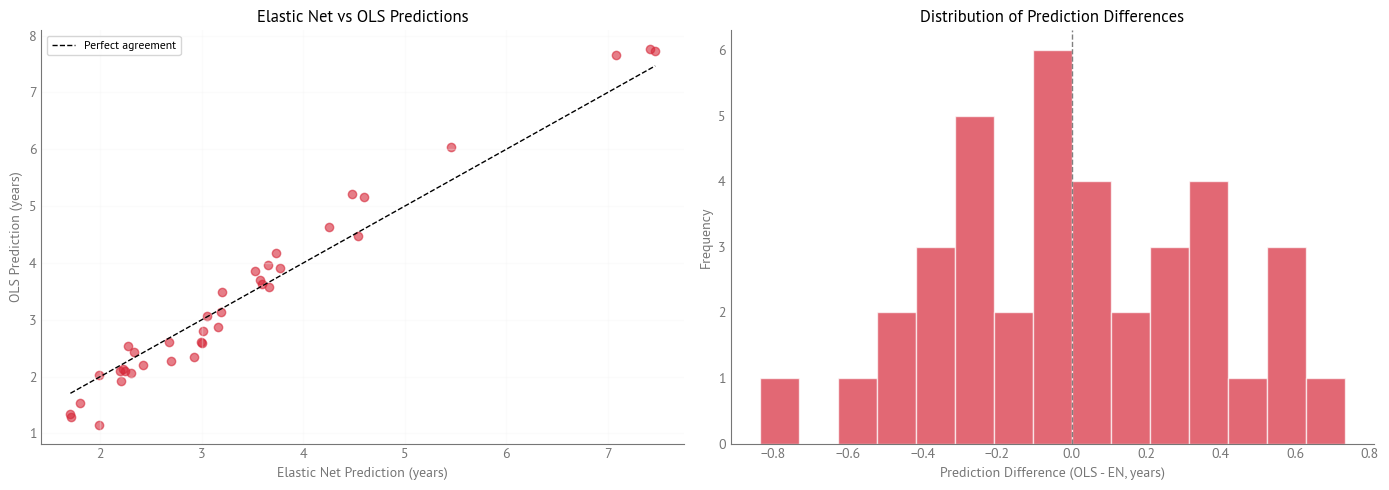

In [44]:
# Visualize prediction differences
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: EN vs OLS predictions
axes[0].scatter(elastic_net_predictions, ols_predictions, 
                color=AIBM_COLORS['crimson'], alpha=0.6)
axes[0].plot([elastic_net_predictions.min(), elastic_net_predictions.max()],
             [elastic_net_predictions.min(), elastic_net_predictions.max()],
             'k--', linewidth=1, label='Perfect agreement')
axes[0].set_xlabel('Elastic Net Prediction (years)')
axes[0].set_ylabel('OLS Prediction (years)')
axes[0].set_title('Elastic Net vs OLS Predictions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram of prediction differences
axes[1].hist(predictions_comparison['Prediction_Difference'], bins=15,
             color=AIBM_COLORS['crimson'], edgecolor='white', alpha=0.7)
axes[1].axvline(x=0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('Prediction Difference (OLS - EN, years)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Prediction Differences')

plt.tight_layout()
plt.savefig(f'jb/figs/predictions_comparison_hale_{cutoff_year}.png', dpi=300, bbox_inches='tight')

In [45]:
# Compare residuals from both models
residuals_comparison = pd.DataFrame({
    'Country': codes_to_country_names(y.index),
    'EN_Residual': y.values - elastic_net_predictions,
    'OLS_Residual': y.values - ols_predictions,
    'Residual_Difference': (y.values - ols_predictions) - (y.values - elastic_net_predictions)
})

residuals_comparison = residuals_comparison.sort_values('Residual_Difference', key=abs, ascending=False)
print("Residual Comparison (Actual - Predicted):")
print("="*60)
print(f"EN MAE: {mean_absolute_error(y, elastic_net_predictions):.4f} years")
print(f"OLS MAE: {mean_absolute_error(y, ols_predictions):.4f} years")
print(f"\nCountries with largest residual differences:")
residuals_comparison.head(10)

Residual Comparison (Actual - Predicted):
EN MAE: 0.4490 years
OLS MAE: 0.3486 years

Countries with largest residual differences:


,Country,EN_Residual,OLS_Residual,Residual_Difference
Code,,,,
DNK,Denmark,-0.398099,0.438873,0.836972
COL,Colombia,0.844864,0.112994,-0.731871
CRI,Costa Rica,-0.845742,-0.263843,0.581900
HUN,Hungary,0.131075,-0.448259,-0.579334
EST,Estonia,0.388311,-0.178307,-0.566617
POL,Poland,1.060050,0.503551,-0.556499
KOR,South Korea,1.182717,0.742306,-0.440411
DEU,Germany,-0.344914,0.080809,0.425722
ISR,Israel,-0.297613,0.127871,0.425484


## Counterfactual Analysis

Counterfactual analysis allows us to answer "what if" questions: What would happen to a country's predicted healthy life expectancy gap if we adjusted a gap predictor to the best attainable value?

For each gap predictor, we find the best case:
- If the current gap is positive (Male > Female), we find the country with the smallest gap (minimum)
- If the current gap is negative (Female > Male), we find the country with the largest gap (maximum, most positive)

To achieve that target gap, we adjust either male or female values:
- If the gap is positive (Male > Female), we bring men toward women's level
- If the gap is negative (Female > Male), we bring women toward men's level

After adjusting Male/Female values, we recompute Mid and Gap values, then use the model to generate the counterfactual prediction.

In [46]:
# Find minimum and maximum gap for each gap predictor across all countries
gap_predictors = [col for col in X.columns if col.startswith('Gap_')]
gap_extremes = {}
for gap_pred in gap_predictors:
    gap_data = X[gap_pred].dropna()
    gap_extremes[gap_pred] = {
        'min_gap': gap_data.min(),
        'min_country': gap_data.idxmin(),
        'max_gap': gap_data.max(),
        'max_country': gap_data.idxmax()
    }

gap_extremes_df = pd.DataFrame(gap_extremes).T
gap_extremes_df

,min_gap,min_country,max_gap,max_country
Gap_Alcohol,0.382924,COL,29.860778,EST
Gap_ChronicRespiratory,-8.432187,ISL,44.704105,BEL
Gap_UnintentionalInjury,-7.418512,DNK,75.308346,EST
Gap_RoadTraffic,5.01033,ISL,31.35789,LVA
Gap_Diabetes,-10.983732,ESP,4.490583,KOR
Gap_Cardiovascular,-128.668566,AUT,24.820997,IRL
Gap_DrugDisorder,0.090494,CHL,8.904232,NOR
Gap_Homicide,-0.005218,AUT,133.395742,COL
Gap_Suicide,2.758182,TUR,67.377919,LTU
Gap_Neoplasms,-1.289751,MEX,130.308588,ESP


In [47]:
def counterfactual_predictions(country, gap_predictor):
    """
    Generate counterfactual prediction by adjusting Male/Female values to achieve best case gap.
    
    Parameters:
    -----------
    country : str
        Country code (e.g., 'USA', 'GBR')
    gap_predictor : str
        Name of the gap predictor column (e.g., 'Gap_Alcohol')
        
    Returns:
    --------
    dict
        Dictionary with counterfactual results including original and adjusted values
    """
    # Extract indicator name from gap predictor (e.g., 'Gap_Alcohol' -> 'Alcohol')
    indicator_name = gap_predictor.replace('Gap_', '')
    
    # Get original Male and Female values from predictors_full
    male_col = f'{indicator_name}_Male'
    female_col = f'{indicator_name}_Female'
    
    original_male = predictors_full.loc[country, male_col]
    original_female = predictors_full.loc[country, female_col]
    original_gap = original_male - original_female
    
    # Determine target gap based on current gap sign
    # If current gap is positive, find minimum gap (best case: smallest positive gap)
    # If current gap is negative, find maximum gap (best case: largest positive gap)
    if original_gap > 0:
        target_gap = gap_extremes[gap_predictor]['min_gap']
        target_country = gap_extremes[gap_predictor]['min_country']
    else:
        target_gap = gap_extremes[gap_predictor]['max_gap']
        target_country = gap_extremes[gap_predictor]['max_country']
    
    # If target gap has opposite sign of current gap, set target to zero
    if (original_gap > 0 and target_gap < 0) or (original_gap < 0 and target_gap > 0):
        target_gap = 0.0
        target_country = ""
    
    # Determine which direction to adjust
    if original_gap > 0:
        # Positive gap: bring men toward women's level
        adjusted_male = original_female + target_gap
        adjusted_female = original_female
    else:
        # Negative gap: bring women toward men's level
        adjusted_male = original_male
        adjusted_female = original_male - target_gap
    
    # Recompute Mid and Gap from adjusted Male/Female
    adjusted_mid = (adjusted_male + adjusted_female) / 2
    adjusted_gap = adjusted_male - adjusted_female
    
    # Get all current predictor values for the country
    counterfactual_data = X.loc[country].copy()
    
    # Update Mid and Gap for this indicator
    mid_col = f'Mid_{indicator_name}'
    counterfactual_data[mid_col] = adjusted_mid
    counterfactual_data[gap_predictor] = adjusted_gap
    
    # Generate prediction
    original_prediction = primary_model.predict(X.loc[country].to_frame().T)[0]
    counterfactual_prediction = primary_model.predict(counterfactual_data.to_frame().T)[0]
    
    return {
        'country': country,
        'indicator': indicator_name,
        'original_male': original_male,
        'original_female': original_female,
        'original_gap': original_gap,
        'target_gap': target_gap,
        'adjusted_male': adjusted_male,
        'adjusted_female': adjusted_female,
        'adjusted_mid': adjusted_mid,
        'adjusted_gap': adjusted_gap,
        'original_prediction': original_prediction,
        'counterfactual_prediction': counterfactual_prediction,
        'change_in_gap': counterfactual_prediction - original_prediction,
        'target_country': target_country
    }

In [48]:
# Example: Counterfactual analysis for USA with Alcohol gap
test_country = 'USA'
test_predictor = 'Gap_Alcohol'

result = counterfactual_predictions(test_country, test_predictor)

# Display summary
print(f"Counterfactual Analysis: {code_to_who_country.get(test_country, test_country)} ({test_country})")
print(f"Indicator: {result['indicator']}")
print(f"\nOriginal values:")
print(f"  Male: {result['original_male']:.3f}")
print(f"  Female: {result['original_female']:.3f}")
print(f"  Gap (Male - Female): {result['original_gap']:.3f}")
if result['target_country']:
    if result['original_gap'] > 0:
        gap_type = "minimum"
    else:
        gap_type = "maximum"
    print(f"\nTarget gap ({gap_type} observed, from {code_to_who_country.get(result['target_country'], result['target_country'])}): {result['target_gap']:.3f}")
else:
    print(f"\nTarget gap (set to zero because best case has opposite sign): {result['target_gap']:.3f}")
print(f"\nAdjusted values to achieve target gap:")
print(f"  Male: {result['adjusted_male']:.3f}")
print(f"  Female: {result['adjusted_female']:.3f}")
print(f"  Gap (Male - Female): {result['adjusted_gap']:.3f}")
print(f"\nPredictions:")
print(f"  Original: {result['original_prediction']:.3f} years")
print(f"  Counterfactual: {result['counterfactual_prediction']:.3f} years")
print(f"  Change: {result['change_in_gap']:.3f} years")

Counterfactual Analysis: United States (USA)
Indicator: Alcohol

Original values:
  Male: 4.943
  Female: 1.378
  Gap (Male - Female): 3.565

Target gap (minimum observed, from Colombia): 0.383

Adjusted values to achieve target gap:
  Male: 1.761
  Female: 1.378
  Gap (Male - Female): 0.383

Predictions:
  Original: 2.304 years
  Counterfactual: 2.235 years
  Change: -0.069 years


In [49]:
# Generate counterfactuals for all gap predictors for a country
def counterfactuals_for_country(country):
    """
    Generate counterfactual predictions for all gap predictors for a given country.
    
    Returns DataFrame with results sorted by importance (descending).
    """
    results = []
    for gap_pred in gap_predictors:
        try:
            result = counterfactual_predictions(country, gap_pred)
            indicator_name = result['indicator']
            
            # Get importance for this indicator
            if indicator_name in indicator_importance_df.index:
                importance = indicator_importance_df.loc[indicator_name, 'Total_Importance']
            else:
                importance = 0.0
            
            # Get country name for target country
            target_country_code = result['target_country']
            if target_country_code:
                target_country_name = code_to_who_country.get(target_country_code, target_country_code)
            else:
                target_country_name = ""
            
            results.append({
                'Indicator': indicator_name,
                'Current gap': result['original_gap'],
                'Target gap': result['target_gap'],
                'Target Country': target_country_name,
                'Change in HALE gap': result['change_in_gap'],
                'Importance': importance
            })
        except (KeyError, ValueError):
            # Skip if indicator doesn't have Male/Female columns (e.g., MaternalMortality)
            continue
    
    df = pd.DataFrame(results)
    # Sort by importance (descending), then select only the columns we want
    df = df.sort_values('Importance', ascending=False)
    df = df[['Indicator', 'Current gap', 'Target gap', 'Target Country', 'Change in HALE gap']]
    return df

# Example: All counterfactuals for USA
usa_counterfactuals = counterfactuals_for_country('USA')
usa_counterfactuals

,Indicator,Current gap,Target gap,Target Country,Change in HALE gap
5,Cardiovascular,-26.544352,0.000000,,-0.008054
9,Neoplasms,21.555842,0.000000,,-0.106596
2,UnintentionalInjury,5.182512,0.000000,,-0.094649
7,Homicide,6.608371,0.000000,,-0.095553
8,Suicide,14.289160,2.758182,Türkiye,-0.296639
1,ChronicRespiratory,0.717529,0.000000,,-0.006157
3,RoadTraffic,12.271515,5.010330,Iceland,-0.305550
10,LiverDisease,8.347310,0.833481,Iceland,-0.081601
0,Alcohol,3.564755,0.382924,Colombia,-0.069412
4,Diabetes,-3.170409,0.000000,,0.020175


In [50]:
# Write counterfactual table to HTML
write_html_table(usa_counterfactuals, f'jb/tables/counterfactuals_usa_hale_{cutoff_year}.html')

In [51]:
target['USA']

2.1904394999999965

In [52]:
gap_closer = usa_counterfactuals['Change in HALE gap'] < 0
usa_counterfactuals.loc[gap_closer]

,Indicator,Current gap,Target gap,Target Country,Change in HALE gap
5,Cardiovascular,-26.544352,0.000000,,-0.008054
9,Neoplasms,21.555842,0.000000,,-0.106596
2,UnintentionalInjury,5.182512,0.000000,,-0.094649
7,Homicide,6.608371,0.000000,,-0.095553
8,Suicide,14.289160,2.758182,Türkiye,-0.296639
1,ChronicRespiratory,0.717529,0.000000,,-0.006157
3,RoadTraffic,12.271515,5.010330,Iceland,-0.305550
10,LiverDisease,8.347310,0.833481,Iceland,-0.081601
0,Alcohol,3.564755,0.382924,Colombia,-0.069412


In [53]:
total = usa_counterfactuals.loc[gap_closer, 'Change in HALE gap'].sum()
total

-1.0642107228555657

In [54]:
total / target['USA'] * 100

-48.58434678773677

In [55]:
gap_widener = usa_counterfactuals['Change in HALE gap'] > 0
usa_counterfactuals.loc[gap_widener]

,Indicator,Current gap,Target gap,Target Country,Change in HALE gap
4,Diabetes,-3.170409,0.000000,,0.020175
6,DrugDisorder,4.462524,0.090494,Chile,0.053261


In [56]:
usa_counterfactuals.loc[gap_widener, 'Change in HALE gap'].sum()

0.07343631042171017

This is based on conservative assumptions:

* Only the gap variables are causal -- for the overall rate variables, we're not sure about the nature of the relationship

* It might not be attainable to close all gaps completely, but we take other countries as evidence: if they have eliminated or remove a gap, that's evidence it's possible. If they are closer to zero, that evidence the gap can be reduced to the level they have achieved.

In [57]:
from utils import beep

beep()